# Amazon DS/Econ RA Interview Simulation: Education ROI Analysis

**Goal:** Determine the wage premium of a Bachelor's degree while controlling for experience and geography.

## Phase 1: Preparation & EDA (30 Minutes)

### Task 1: Data Loading & Subset

* Load the CPS dataset. -> clean_nov25pub.csv
* Filter for ages 18-65 and `wage_hourly > 0`.
* Create `log_wage` using `np.log()` and `is_college` (1 if code == 43, else 0).?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# YOUR CODE HERE: Load, Filter, and Feature Engineering
df = pd.read_csv("../data/clean_nov25pub.csv")
print(df.info())
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121723 entries, 0 to 121722
Data columns (total 23 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   age               90299 non-null   float64
 1   sex               90299 non-null   float64
 2   race              90299 non-null   float64
 3   marital_status    90299 non-null   float64
 4   education         90299 non-null   float64
 5   hispanic          90299 non-null   float64
 6   lfs               90299 non-null   float64
 7   hours_usual       90299 non-null   float64
 8   wage_hourly       90299 non-null   float64
 9   wage_weekly       90299 non-null   float64
 10  weeks_worked      90299 non-null   float64
 11  region            121723 non-null  int64  
 12  state             121723 non-null  int64  
 13  metro_size        121723 non-null  int64  
 14  metro_status      121723 non-null  int64  
 15  wt_person         90299 non-null   float64
 16  wt_family         90

Index(['age', 'sex', 'race', 'marital_status', 'education', 'hispanic', 'lfs',
       'hours_usual', 'wage_hourly', 'wage_weekly', 'weeks_worked', 'region',
       'state', 'metro_size', 'metro_status', 'wt_person', 'wt_family',
       'hhid1', 'hhid2', 'line_no', 'topcode_age_flag', 'hhid', 'person_id'],
      dtype='object')

In [2]:
# TODO: Filter for ages 18-65 and `wage_hourly > 0`
age_mask = (df['age'] >= 18) & (df['age'] <= 65)
wage_mask = df['wage_hourly'] > 0
df = df.loc[age_mask & wage_mask].copy()

# TODO: Create `log_wage` using `np.log()` and `is_college` (1 if code == 43, else 0)
df['log_wage'] = np.log(df['wage_hourly'])
df['is_college'] = np.where(df['education'] >= 43, 1, 0)

### Task 2: Visualizing the Relationship

* Create a scatter plot of `age` vs `log_wage`.
* Use `hue='is_college'` to see if the slopes look different.

> **💡 Pro-Tip (Narration):** "I'm checking for life-cycle wage patterns. Notice how wages tend to rise with age but potentially flatten out—this suggests a non-linear relationship with experience that I'll need to model."

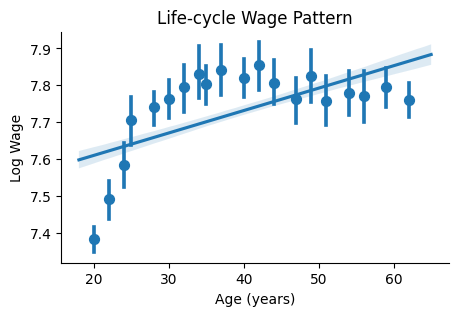

In [3]:
# 1. create figure and axis
fig, ax = plt.subplots(figsize=(5, 3))

# 2. use seaborn but pass it as ax
sns.regplot(data=df, x='age', y='log_wage', x_bins=20, ax=ax)

# 3. use the ax for edits
ax.set_title('Life-cycle Wage Pattern')
ax.set_xlabel('Age (years)')
ax.set_ylabel('Log Wage')
sns.despine()

## Phase 2: Multivariate Modeling (40 Minutes)

### Task 3: The Baseline vs. The Controlled Model

* Run Model A: `log_wage ~ is_college`
* Run Model B: `log_wage ~ is_college + age + age_sq` (Note: You'll need to create an `age_sq` column).

In [4]:
# YOUR CODE HERE: Fit both models using sm.OLS and sm.add_constant()
X = df['is_college']
y = df['log_wage']
X = sm.add_constant(X)

model_univar = sm.OLS(y, X)
result_univar = model_univar.fit()
print(result_univar.summary())

                            OLS Regression Results                            
Dep. Variable:               log_wage   R-squared:                       0.068
Model:                            OLS   Adj. R-squared:                  0.067
Method:                 Least Squares   F-statistic:                     359.6
Date:                Fri, 23 Jan 2026   Prob (F-statistic):           1.84e-77
Time:                        08:46:52   Log-Likelihood:                -3105.9
No. Observations:                4958   AIC:                             6216.
Df Residuals:                    4956   BIC:                             6229.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          7.6607      0.007   1035.755      0.0

In [5]:
# Model B: `log_wage ~ is_college + age + age_sq`
# Create quadratic term for age
df['age_sqr'] = df['age'] ** 2

X = df[['is_college', 'age', 'age_sqr']]
y = df['log_wage']
X = sm.add_constant(X)

model_multi = sm.OLS(y, X)
result_multi = model_multi.fit()
print(result_multi.summary())

                            OLS Regression Results                            
Dep. Variable:               log_wage   R-squared:                       0.120
Model:                            OLS   Adj. R-squared:                  0.119
Method:                 Least Squares   F-statistic:                     224.9
Date:                Fri, 23 Jan 2026   Prob (F-statistic):          9.00e-137
Time:                        08:46:52   Log-Likelihood:                -2963.1
No. Observations:                4958   AIC:                             5934.
Df Residuals:                    4954   BIC:                             5960.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          6.7373      0.060    112.811      0.0

### Task 4: Incorporating Fixed Effects

* Use `pd.get_dummies()` to handle the `state` variable.
* **Note:** Use `drop_first=True` to avoid the "Dummy Variable Trap."

> **💡 Pro-Tip (Narration):** "By adding state fixed effects, I'm controlling for time-invariant local characteristics like cost of living or state-specific labor laws that might be correlated with both education levels and wages."

In [6]:
import statsmodels.formula.api as smf

# 'C()' tells statsmodels to treat the variable as categorical (Fixed Effect)
model = smf.ols('log_wage ~ is_college + age + age_sqr + C(state)', data=df)
result = model.fit()
print(result.summary())

                            OLS Regression Results                            
Dep. Variable:               log_wage   R-squared:                       0.153
Model:                            OLS   Adj. R-squared:                  0.144
Method:                 Least Squares   F-statistic:                     16.75
Date:                Fri, 23 Jan 2026   Prob (F-statistic):          4.41e-138
Time:                        08:46:52   Log-Likelihood:                -2867.0
No. Observations:                4958   AIC:                             5842.
Df Residuals:                    4904   BIC:                             6194.
Df Model:                          53                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          6.7214      0.076     88.

## Phase 3: Causal Inference & Interaction (30 Minutes)

### Task 5: The Interaction Effect

* Create an interaction term: `df['college_age_interaction'] = df['is_college'] * df['age']`.
* Run the model: `log_wage ~ is_college + age + age_sq + college_age_interaction`.

In [7]:
df['college_age_interaction'] = df['is_college'] * df['age']

model = smf.ols('log_wage ~ is_college + age + age_sqr + college_age_interaction', data=df)
result = model.fit()
print(result.summary())

                            OLS Regression Results                            
Dep. Variable:               log_wage   R-squared:                       0.120
Model:                            OLS   Adj. R-squared:                  0.119
Method:                 Least Squares   F-statistic:                     168.7
Date:                Fri, 23 Jan 2026   Prob (F-statistic):          1.32e-135
Time:                        08:46:52   Log-Likelihood:                -2963.0
No. Observations:                4958   AIC:                             5936.
Df Residuals:                    4953   BIC:                             5968.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

### Task 6: Diagnostic Check (Heteroskedasticity)

* Plot the residuals () against the predicted values ().

> **💡 Pro-Tip (Narration):** "If I see a 'fan shape' in my residuals, it indicates heteroskedasticity. In a production environment, I would use Robust Standard Errors (HC3) to ensure my p-values remain valid under non-constant variance.

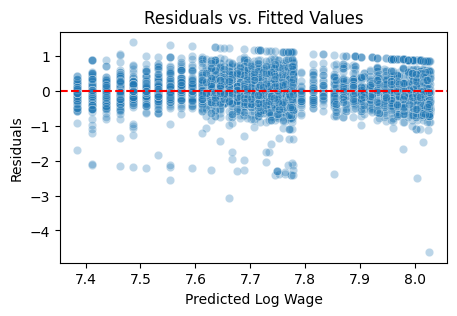

In [8]:
# 1. Get the values from the model result object
fitted_vals = result.fittedvalues
residuals = result.resid

# 2. Plotting
plt.figure(figsize=(5, 3))
sns.scatterplot(x=fitted_vals, y=residuals, alpha=0.3)
plt.axhline(0, color='red', linestyle='--')  # Add a horizontal line at 0

plt.title('Residuals vs. Fitted Values')
plt.xlabel('Predicted Log Wage')
plt.ylabel('Residuals')
plt.show()

I'm checking the Gauss-Markov assumptions here—specifically homoskedasticity. In wage models, we often see the error variance increase with income. If this residual plot shows a non-constant 'fan' pattern, my standard errors will be inefficient. To stay 'Data-Driven' and ensure my inference is robust, I would re-estimate this using Huber-White Robust Standard Errors (HC3).

In [9]:
# Re-fitting with robust standard errors (HC3 is the gold standard)
robust_model = result.get_robustcov_results(cov_type='HC3')
print(robust_model.summary())

                            OLS Regression Results                            
Dep. Variable:               log_wage   R-squared:                       0.120
Model:                            OLS   Adj. R-squared:                  0.119
Method:                 Least Squares   F-statistic:                     159.5
Date:                Fri, 23 Jan 2026   Prob (F-statistic):          1.32e-128
Time:                        08:46:52   Log-Likelihood:                -2963.0
No. Observations:                4958   AIC:                             5936.
Df Residuals:                    4953   BIC:                             5968.
Df Model:                           4                                         
Covariance Type:                  HC3                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

## Phase 4: Executive Summary (20 Minutes)

**Write your findings below as if reporting to a Senior Manager:**

1. **The Result:** 2. **The Nuance:** 3. **The Risk (Identification Challenge):** 4. **The Business Recommendation:** 

# The Gender Wage Gap Analysis
### Jan. 20th 2026
**Business Case:** Amazon's DEI (Diversity, Equity, and Inclusion) team wants a data-driven audit of wage structures. You must determine if a statistical difference in pay exists between male and female workers after controlling for human capital variables.

## Phase 1: High-Speed EDA & Variable Setup (25 Minutes)

### Task 1: Data Prep

* Filter for ages 25-65 (to focus on the core workforce) and positive wages.
* Create `is_female` (1 if Female, 0 if Male).
* Create `log_wage`.

In [10]:
# TODO
age_mask = (df['age'] >= 25) & (df['age'] <= 65)
df['is_female'] = np.where(df['sex'] == 2, 1, 0)
df['log_wage'] = np.log(df['wage_hourly'])

### Task 2: The "Descriptive Statistics" Table

Amazon interviewers often ask for a "Table 1"—a summary of means by group.

* Create a table showing the mean `wage_hourly`, `age`, and `education` for men vs. women.

> **💡 Pro-Tip (Narration):** "Before modeling, I'm checking for 'balance' in my covariates. If men in this sample have significantly more years of education than women, a simple average wage comparison will be biased by education, not just gender."

In [11]:
df_filtered = df.loc[age_mask, :]

table1 = df_filtered.groupby('is_female')[['log_wage', 'age', 'is_college']].mean()
table1

,log_wage,age,is_college
is_female,,,
0,7.859717,42.730865,0.214607
1,7.716438,43.915770,0.327562


## Phase 2: The Regression (40 Minutes)

### Task 3: Iterative Modeling

You will build three models to show how the "Gender Penalty" changes as you add controls.

* **Model 1 (Raw Gap):** `log_wage ~ is_female`
* **Model 2 (Human Capital):** `log_wage ~ is_female + age + age_sq + education`
* **Model 3 (Full Controls):** Add `state` fixed effects to Model 2.

In [12]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

df_filtered['age_sqr'] = df_filtered['age'] ** 2

m1 = smf.ols('log_wage ~ is_female', data=df_filtered).fit()

m2 = smf.ols('log_wage ~ is_female + age + age_sqr + is_college', data=df_filtered).fit()

m3 = smf.ols('log_wage ~ is_female + age + age_sqr + is_college + C(state)', data=df_filtered).fit()

print(f"Model 1: Naive Gap Between Gender: {m1.summary()}")
print(f"Model 2: Human Capital: {m2.summary()}")
print(f"Model 3: Adding State fixed effects: {m3.summary()}")

Model 1: Naive Gap Between Gender:                             OLS Regression Results                            
Dep. Variable:               log_wage   R-squared:                       0.024
Model:                            OLS   Adj. R-squared:                  0.024
Method:                 Least Squares   F-statistic:                     101.7
Date:                Fri, 23 Jan 2026   Prob (F-statistic):           1.23e-23
Time:                        08:46:52   Log-Likelihood:                -2625.9
No. Observations:                4136   AIC:                             5256.
Df Residuals:                    4134   BIC:                             5269.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      7.

/var/folders/n2/8hz3y3r90rj63gkzgrl1hwg40000gn/T/ipykernel_27023/2240415010.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['age_sqr'] = df_filtered['age'] ** 2


### Task 4: Hypothesis Testing

* Extract the p-value for the `is_female` coefficient in Model 3.
* Is the gap statistically significant at the 1% level?

In [13]:
female_p = m3.pvalues['is_female']

print(f"{female_p:.6f}")

0.000000


the p value is tiny basically less than 0.000001, my understanidng is that this is due to the smalll standard error due to the size of the dataset, because as sample size increases, the SE becomes smaller and it's easy to get a significant result

## Phase 3: Causal Nuance & Non-Linearity (35 Minutes)

### Task 5: The "Experience Premium" Interaction

Does the market reward experience differently for men and women?

* Run a model with an **interaction term**: `is_female * age`.
* Visualize this using `sns.lmplot` to show two regression lines: one for men and one for women.

> **💡 Pro-Tip (Narration):** "I’m testing for a 'differential return to experience.' If the slope for women is flatter than for men, it suggests that the wage gap widens as careers progress, which is a common finding in labor economics due to potential career interruptions."

<Figure size 400x800 with 0 Axes>

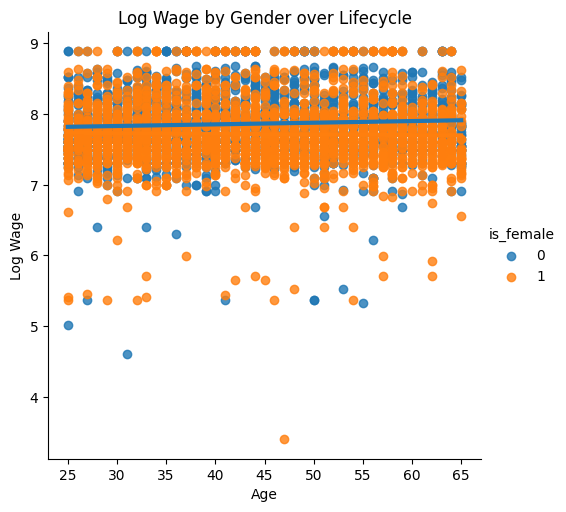

In [14]:
import seaborn as sns
import statsmodels.formula.api as smf

model_inter = smf.ols('log_wage ~ is_female * age + age + age_sqr + is_college + C(state)', data=df_filtered).fit()

# model_inter.summary()

plt.figure(figsize=(4,8))
sns.lmplot(x='age', y='log_wage', hue='is_female', data=df_filtered, line_kws={'lw':3})

plt.title("Log Wage by Gender over Lifecycle")
plt.xlabel('Age')
plt.ylabel('Log Wage')
plt.show()

## Phase 4: Business Synthesis & Bar-Raiser Prep (20 Minutes)

**Imagine the "Bar Raiser" asks: "Your model shows a 5% gap. Does this prove discrimination?" Write your response:**

1. **The Interpretation:** Explain the 5% in terms of "unexplained variance."
2. **The Omitted Variable Bias:** Identify 2 variables NOT in the CPS (e.g., specific college major, "soft skills", or hours worked) that might explain the remaining gap.
3. **The Econometric Fix:** Briefly explain how a **Fixed Effects** model at the "Firm Level" (if you had the data) would provide a cleaner estimate than this "State Level" model.

3. In terms of **Fixed Effects** at the "Firm Level", it would provide a cleaner estimate than state level because of omitted variable bias and provide more controls. 

## Practice (ref: P4DA)

In [15]:
# To make the example reproducible
rng = np.random.default_rng(seed=12345)

def dnorm(mean, variance, size=1):
    if isinstance(size, int):
        size = size,
    return mean + np.sqrt(variance) * rng.standard_normal(*size)

N = 100
X = np.c_[dnorm(0, 0.4, size=N),
          dnorm(0, 0.6, size=N),
          dnorm(0, 0.2, size=N)]
eps = dnorm(0, 0.1, size=N)
beta = [0.1, 0.3, 0.5]

y = np.dot(X, beta) + eps